In [1]:
!nvidia-smi

Wed Apr 15 23:14:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Installing libraries

In [2]:
!pip install ultralytics
!pip install fastapi
!pip install uvicorn
!pip install python-multipart
!pip install pyngrok
!pip install onnx
!pip install onnxruntime-gpu
!pip install opencv-python-headless
!pip install Pillow
!pip install nest-asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 4.2 MB/s eta 0:00:00


In [3]:
import torch
import ultralytics
import cv2
import onnxruntime

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Ultralytics version: {ultralytics.__version__}")
print(f"ONNX Runtime version: {onnxruntime.__version__}")
print(f"OpenCV version: {cv2.__version__}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.10.0+cu128
CUDA available: True
Ultralytics version: 8.4.37
ONNX Runtime version: 1.24.4
OpenCV version: 4.13.0


## Load Model

In [4]:
from ultralytics import YOLO

# Model 1: YOLOv8
yolo_model = YOLO('yolov8n.pt')

# Model 2: RT-DETR (transformer-based)
rtdetr_model = YOLO('rtdetr-l.pt')

print("✅ Both models loaded successfully!")

✅ Both models loaded successfully!


In [5]:
import urllib.request

# Downloading a sample traffic image for testing
urllib.request.urlretrieve(
    "https://ultralytics.com/images/bus.jpg",
    "test_image.jpg"
)
print("✅ Test image downloaded!")


✅ Test image downloaded!


## Running inference with both models and compare


Model: YOLOv8n
Latency: 17.00 ms
Objects detected: 6
  → bus: 0.87 confidence
  → person: 0.87 confidence
  → person: 0.85 confidence
  → person: 0.83 confidence
  → person: 0.26 confidence
  → stop sign: 0.26 confidence

Model: RT-DETR-L
Latency: 75.42 ms
Objects detected: 9
  → bus: 0.96 confidence
  → person: 0.95 confidence
  → person: 0.95 confidence
  → person: 0.93 confidence
  → person: 0.86 confidence
  → fire hydrant: 0.34 confidence
  → traffic light: 0.28 confidence
  → tie: 0.27 confidence
  → tie: 0.26 confidence


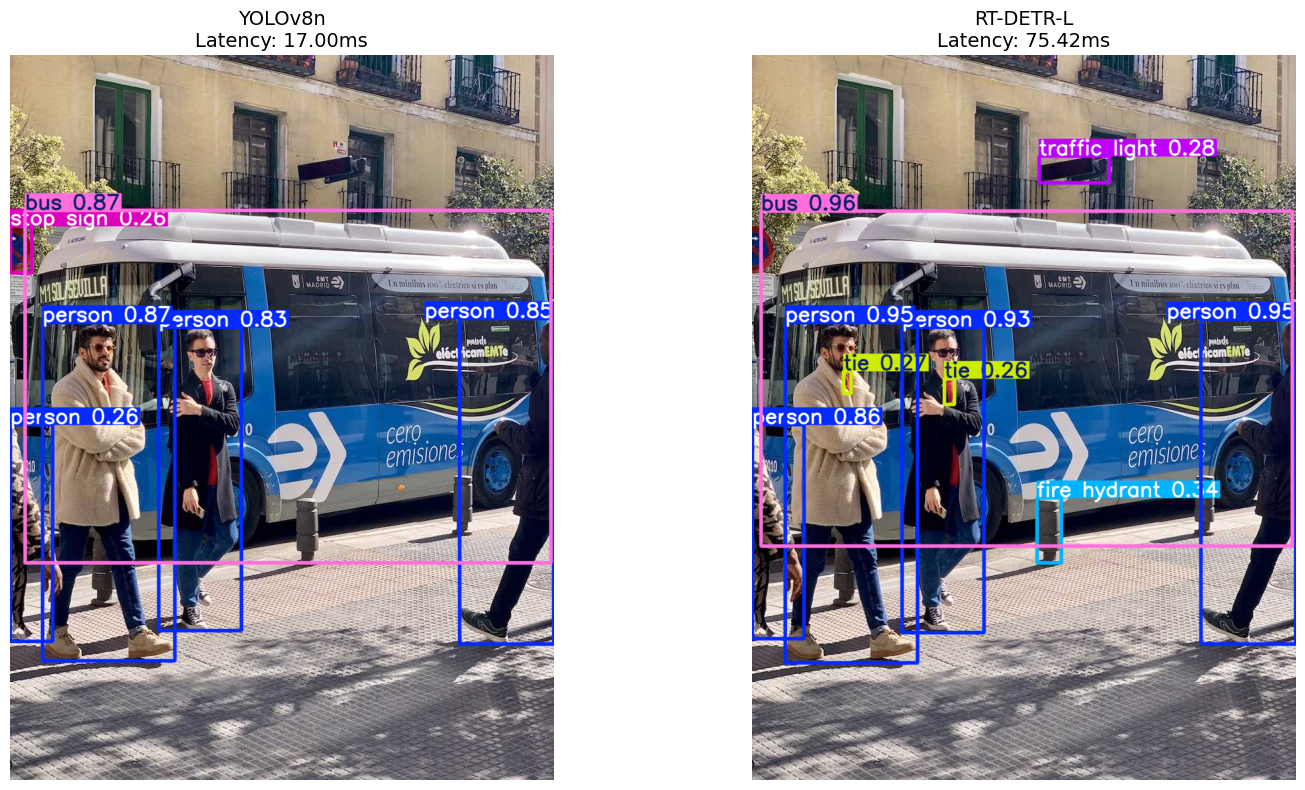


✅ Side-by-side comparison saved!


In [6]:
import cv2
import time
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

def run_inference(model, image_path, model_name):
    # Warmup
    model(image_path, verbose=False)

    # Timed inference
    start = time.time()
    results = model(image_path, verbose=False)
    end = time.time()

    latency = (end - start) * 1000  # ms

    # Draw results
    annotated = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    # Count detections
    boxes = results[0].boxes
    print(f"\n{'='*40}")
    print(f"Model: {model_name}")
    print(f"Latency: {latency:.2f} ms")
    print(f"Objects detected: {len(boxes)}")
    if len(boxes) > 0:
        for box in boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            label = model.names[cls_id]
            print(f"  → {label}: {conf:.2f} confidence")
    print(f"{'='*40}")

    return annotated_rgb, latency

# Run both models
yolo_img, yolo_latency = run_inference(yolo_model, "test_image.jpg", "YOLOv8n")
rtdetr_img, rtdetr_latency = run_inference(rtdetr_model, "test_image.jpg", "RT-DETR-L")

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(yolo_img)
axes[0].set_title(f"YOLOv8n\nLatency: {yolo_latency:.2f}ms", fontsize=14)
axes[0].axis('off')

axes[1].imshow(rtdetr_img)
axes[1].set_title(f"RT-DETR-L\nLatency: {rtdetr_latency:.2f}ms", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Side-by-side comparison saved!")

## Evaluation

In [7]:
from google.colab import files
import os

print("Upload your Roboflow dataset zip file...")
uploaded = files.upload()  # triggers file picker

zip_name = list(uploaded.keys())[0]
print(f"✅ Uploaded: {zip_name}")


Upload your Roboflow dataset zip file...


Saving DL_ObjectDetection2.0.yolov8.zip to DL_ObjectDetection2.0.yolov8.zip
✅ Uploaded: DL_ObjectDetection2.0.yolov8.zip


In [8]:
import zipfile

# Peek inside zip without extracting
with zipfile.ZipFile(zip_name, 'r') as z:
    # List all files
    all_files = z.namelist()
    label_files = [f for f in all_files if f.endswith('.txt') and 'label' in f.lower()]

    print(f"Total files in zip: {len(all_files)}")
    print(f"\nFirst few label files:")
    for f in label_files[:3]:
        print(f"\n--- {f} ---")
        with z.open(f) as lf:
            content = lf.read().decode('utf-8')
            # Show first 3 lines
            for line in content.split('\n')[:3]:
                if line.strip():
                    parts = line.strip().split()
                    print(f"Class: {parts[0]}, Total numbers: {len(parts)-1}")
                    print(f"Raw: {line[:100]}...")

Total files in zip: 148

First few label files:

--- train/labels/WhatsApp Video 2026-04-12 at 19_06_28_mp4-0012_jpg.rf.ex5b3yg2n7zmIfV2sLcM.txt ---

--- train/labels/WhatsApp Video 2026-04-12 at 19_06_28_mp4-0002_jpg.rf.amgpjKgcjmuVesRl6wn5.txt ---
Class: 0, Total numbers: 34
Raw: 0 0.6709905660377359 0.5690376569037657 0.6745283018867925 0.5774058577405857 0.6745283018867925 0.5...
Class: 0, Total numbers: 34
Raw: 0 0.5908018867924528 0.5669456066945606 0.6002358490566038 0.5857740585774058 0.6025943396226415 0.5...
Class: 1, Total numbers: 46
Raw: 1 0.964622641509434 0.5815899581589958 0.9764150943396226 0.5920502092050209 0.9870283018867925 0.58...

--- train/labels/WhatsApp Video 2026-04-12 at 19_06_28_mp4-0010_jpg.rf.eWT1vrdgiHrQYqJFdYwG.txt ---
Class: 1, Total numbers: 56
Raw: 1 0.6816037735849056 0.6820083682008368 0.7051886792452831 0.6882845188284519 0.7122641509433962 0.6...


In [9]:
import shutil

# Extract fresh copy
if os.path.exists('dataset_fresh'):
    shutil.rmtree('dataset_fresh')

zip_name = 'DL_ObjectDetection2.0.yolov8.zip'
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('dataset_fresh')

# Convert polygon labels to bounding boxes
label_dir = 'dataset_fresh/train/labels'
label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]

print(f"Converting {len(label_files)} files...")

converted = 0
skipped = 0

for label_file in label_files:
    path = os.path.join(label_dir, label_file)
    with open(path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            skipped += 1
            continue

        cls_id = parts[0]
        coords = list(map(float, parts[1:]))

        # Must have even number of coords (x,y pairs)
        if len(coords) % 2 != 0:
            coords = coords[:-1]

        xs = coords[0::2]
        ys = coords[1::2]

        # Clamp to [0,1]
        xs = [max(0, min(1, x)) for x in xs]
        ys = [max(0, min(1, y)) for y in ys]

        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)

        x_center = (x_min + x_max) / 2
        y_center = (y_min + y_max) / 2
        width    = x_max - x_min
        height   = y_max - y_min

        # Skip if box is too large (likely corrupt)
        if width > 0.9 or height > 0.9:
            skipped += 1
            continue

        # Skip if box is too small (noise)
        if width < 0.01 or height < 0.01:
            skipped += 1
            continue

        new_lines.append(
            f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n"
        )
        converted += 1

    with open(path, 'w') as f:
        f.writelines(new_lines)

print(f"✅ Converted: {converted} boxes")
print(f"⚠️ Skipped (corrupt/too large/too small): {skipped}")

Converting 73 files...
✅ Converted: 3607 boxes
⚠️ Skipped (corrupt/too large/too small): 199


In [10]:
import os

label_dir = 'dataset_fresh/train/labels'
label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]

# Roboflow order → COCO order mapping
# Roboflow: 0=bicycle, 1=car, 2=person
# COCO:     0=person,  1=bicycle, 2=car
remap = {
    0: 1,  # bicycle stays 1
    1: 2,  # car becomes 2
    2: 0   # person becomes 0
}

for label_file in label_files:
    path = os.path.join(label_dir, label_file)
    with open(path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            old_cls = int(parts[0])
            new_cls = remap.get(old_cls, old_cls)
            new_lines.append(f"{new_cls} {parts[1]} {parts[2]} {parts[3]} {parts[4]}\n")

    with open(path, 'w') as f:
        f.writelines(new_lines)

print("✅ Class IDs remapped!")
print("bicycle(0)→1, car(1)→2, person(2)→0")

✅ Class IDs remapped!
bicycle(0)→1, car(1)→2, person(2)→0


In [11]:
import yaml

with open('dataset_fresh/data.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Update to COCO order
config['names'] = ['person', 'bicycle', 'car']
config['train'] = '/content/dataset_fresh/train/images'
config['val']   = '/content/dataset_fresh/train/images'
config['test']  = '/content/dataset_fresh/train/images'

with open('dataset_fresh/data.yaml', 'w') as f:
    yaml.dump(config, f)

print(f"✅ data.yaml updated!")
print(f"Classes: {config['names']}")

✅ data.yaml updated!
Classes: ['person', 'bicycle', 'car']


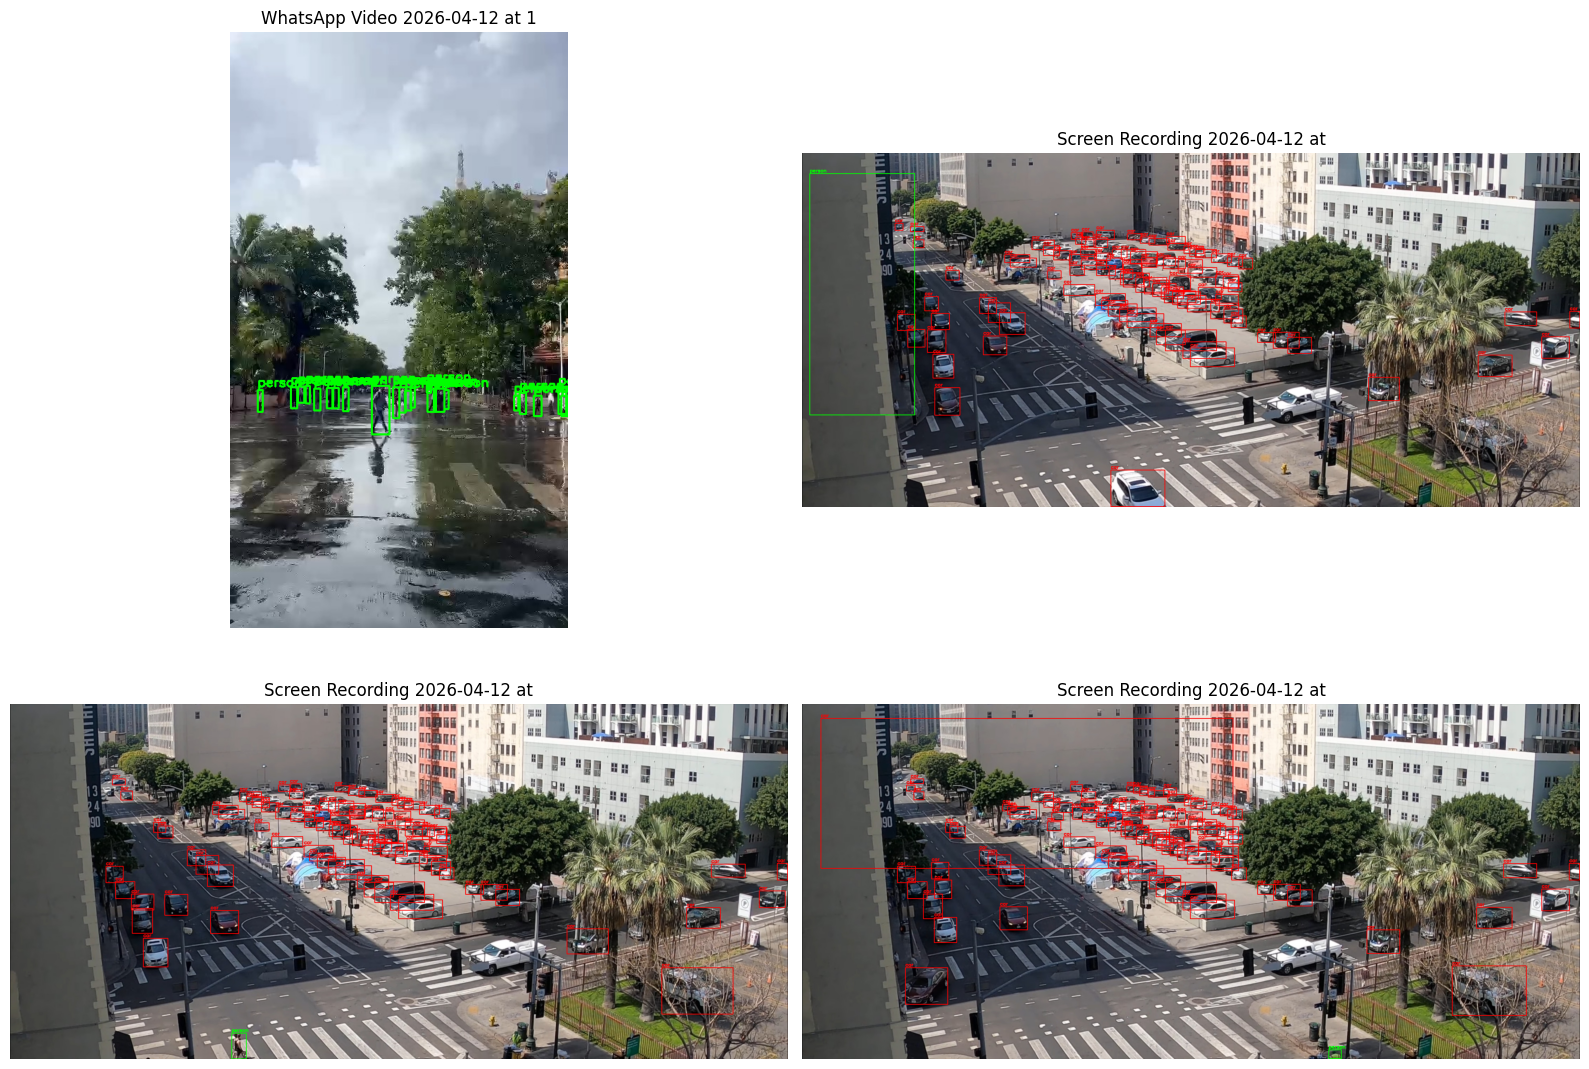

✅ Visual check done!


In [12]:
import cv2
import matplotlib.pyplot as plt

img_dir = 'dataset_fresh/train/images'
label_dir = 'dataset_fresh/train/labels'
img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]

names  = {0:'person', 1:'bicycle', 2:'car'}
colors = {0:(0,255,0), 1:(255,0,0), 2:(0,0,255)}

fig, axes = plt.subplots(2, 2, figsize=(16,12))
axes = axes.flatten()

for idx, img_file in enumerate(img_files[:4]):
    label_file = img_file.replace('.jpg', '.txt')
    label_path = os.path.join(label_dir, label_file)
    img = cv2.imread(os.path.join(img_dir, img_file))
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls = int(parts[0])
                x,y,bw,bh = float(parts[1]),float(parts[2]),float(parts[3]),float(parts[4])
                x1=int((x-bw/2)*w); y1=int((y-bh/2)*h)
                x2=int((x+bw/2)*w); y2=int((y+bh/2)*h)
                cv2.rectangle(img,(x1,y1),(x2,y2),colors.get(cls,(255,255,255)),2)
                cv2.putText(img,names.get(cls,str(cls)),(x1,max(0,y1-5)),
                           cv2.FONT_HERSHEY_SIMPLEX,0.6,colors.get(cls,(255,255,255)),2)

    axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(img_file[:30])
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('fixed_annotations.png', dpi=150)
plt.show()
print("✅ Visual check done!")

## Evaluating Yolov8 on custom dataset

In [13]:
print("\nEvaluating YOLOv8...")
yolo_model = YOLO('yolov8n.pt')
yolo_results = yolo_model.val(
    data='/content/dataset_fresh/data.yaml',
    split='val',
    imgsz=640,
    conf=0.25,
    iou=0.5,
    device=0,
)

print("\n" + "="*40)
print("YOLOv8 Results")
print("="*40)
print(f"mAP50:     {yolo_results.box.map50:.4f}")
print(f"mAP50-95:  {yolo_results.box.map:.4f}")
print(f"Precision: {yolo_results.box.mp:.4f}")
print(f"Recall:    {yolo_results.box.mr:.4f}")
print("="*40)



Evaluating YOLOv8...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3023.4±1868.4 MB/s, size: 558.1 KB)
val: Scanning /content/dataset_fresh/train/labels... 73 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 1.9Kit/s 0.0s
val: New cache created: /content/dataset_fresh/train/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.6s/it 7.8s
                   all         73       3607      0.829      0.252       0.24      0.135
                person         56        416      0.807      0.341      0.328      0.195
               bicycle         19         70      0.895      0.243      0.241      0.118
                   car         65       3121      0.786      0.172      0.152     0.0911
Speed: 6.9ms preprocess, 14.1ms inference, 0.0ms los

In [14]:
print("\nEvaluating RT-DETR...")
rtdetr_model = YOLO('rtdetr-l.pt')
rtdetr_results = rtdetr_model.val(
    data='/content/dataset_fresh/data.yaml',
    split='val',
    imgsz=640,
    conf=0.25,
    iou=0.5,
    device=0,
)

print("\n" + "="*40)
print("RT-DETR-L Results")
print("="*40)
print(f"mAP50:     {rtdetr_results.box.map50:.4f}")
print(f"mAP50-95:  {rtdetr_results.box.map:.4f}")
print(f"Precision: {rtdetr_results.box.mp:.4f}")
print(f"Recall:    {rtdetr_results.box.mr:.4f}")
print("="*40)

# Side-by-side comparison
print("\n" + "="*55)
print(f"{'Metric':<15} {'YOLOv8n':>15} {'RT-DETR-L':>15}")
print("="*55)
print(f"{'mAP50':<15} {yolo_results.box.map50:>15.4f} {rtdetr_results.box.map50:>15.4f}")
print(f"{'mAP50-95':<15} {yolo_results.box.map:>15.4f} {rtdetr_results.box.map:>15.4f}")
print(f"{'Precision':<15} {yolo_results.box.mp:>15.4f} {rtdetr_results.box.mp:>15.4f}")
print(f"{'Recall':<15} {yolo_results.box.mr:>15.4f} {rtdetr_results.box.mr:>15.4f}")
print("="*55)



Evaluating RT-DETR...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 294 layers, 32,148,140 parameters, 0 gradients, 103.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3582.8±1296.6 MB/s, size: 542.5 KB)
val: Scanning /content/dataset_fresh/train/labels.cache... 73 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 23.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.9s/it 9.4s
                   all         73       3607      0.669      0.453      0.426      0.292
                person         56        416       0.48      0.577      0.511      0.303
               bicycle         19         70      0.694      0.519      0.497        0.4
                   car         65       3121      0.834      0.262      0.269      0.174
Speed: 8.9ms preprocess, 57.5ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/run

**mAP50 and mAP50-95** : RT-DETR's mAP50 of 0.43 vs YOLOv8's 0.24 means RT-DETR is roughly 77% more accurate at finding and correctly localizing objects. The mAP50-95 gap (0.29 vs 0.13) shows the same story holds even when we demand tighter bounding box fits. \
\
**Precision (0.83 vs 0.67)** : YOLOv8 is right 83% of the time, vs RT-DETR's 67%. YOLOv8 makes fewer false alarms. \
\
**Recall (0.25 vs 0.45)** : YOLOv8'only finds 25% of the actual objects in your images. RT-DETR finds 45%. YOLOv8 is missing a huge number of real objects entirely i.e., it's being very conservative about what it flags.

## Export both models to ONNX format

In [15]:
# Export YOLOv8 to ONNX
print("Exporting YOLOv8 to ONNX...")
yolo_model.export(format='onnx', dynamic=False, simplify=True)
print("✅ YOLOv8 ONNX exported!")

Exporting YOLOv8 to ONNX...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.71'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 195ms
Prepared 2 packages in 32ms
Installed 2 packages in 7ms
 + colorama==0.4.6
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 2.7s, saved as 'yolov8n.onnx' (12.3 MB)

Export complete (3.0s)
Results saved to /content
Predict:         yolo predict ta

In [16]:
print("Exporting RT-DETR to ONNX...")
rtdetr_model_cpu = YOLO('rtdetr-l.pt')

# Move model to CPU explicitly before export
rtdetr_model_cpu.export(
    format='onnx',
    dynamic=False,
    simplify=True,
    device='cpu'
)
print("✅ RT-DETR ONNX exported!")

Exporting RT-DETR to ONNX...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
rt-detr-l summary: 294 layers, 32,148,140 parameters, 0 gradients, 103.8 GFLOPs

PyTorch: starting from 'rtdetr-l.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 84) (63.4 MB)

ONNX: starting export with onnx 1.21.0 opset 20...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/jit_utils.py:305: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at /pytorch/torch/csrc/jit/passes/onnx/constant_fold.cpp:178.)
  _C._jit_pass_onnx_node_shape_type_inference(node, params_dict, opset_version)
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:714: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice

ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 19.5s, saved as 'rtdetr-l.onnx' (125.6 MB)

Export complete (24.3s)
Results saved to /content
Predict:         yolo predict task=detect model=rtdetr-l.onnx imgsz=640 
Validate:        yolo val task=detect model=rtdetr-l.onnx imgsz=640 data=None  
Visualize:       https://netron.app
✅ RT-DETR ONNX exported!


## ONNX Runtime with CUDA


In [17]:
import onnxruntime as ort
import numpy as np
import cv2
import time

def load_onnx_session(onnx_path):
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
    session = ort.InferenceSession(onnx_path, providers=providers)
    print(f"✅ Loaded: {onnx_path}")
    print(f"   Provider: {session.get_providers()[0]}")
    return session

def onnx_inference_timed(session, image_path, runs=10):
    # Preprocess
    img = cv2.imread(image_path)
    img_resized = cv2.resize(img, (640, 640))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_normalized = img_rgb.astype(np.float32) / 255.0
    img_input = np.expand_dims(np.transpose(img_normalized, (2, 0, 1)), axis=0)
    input_name = session.get_inputs()[0].name

    # Warmup
    for _ in range(3):
        session.run(None, {input_name: img_input})

    # Timed runs (average over multiple runs for accuracy)
    latencies = []
    for _ in range(runs):
        start = time.time()
        session.run(None, {input_name: img_input})
        latencies.append((time.time() - start) * 1000)

    return np.mean(latencies), np.std(latencies)

# Load ONNX sessions
print("Loading ONNX models...\n")
yolo_session = load_onnx_session('yolov8n.onnx')
rtdetr_session = load_onnx_session('rtdetr-l.onnx')

# Run timed inference
print("\nRunning inference (10 runs each)...")
yolo_onnx_mean, yolo_onnx_std = onnx_inference_timed(yolo_session, 'test_image.jpg')
rtdetr_onnx_mean, rtdetr_onnx_std = onnx_inference_timed(rtdetr_session, 'test_image.jpg')

print(f"\n{'='*45}")
print(f"{'Model':<15} {'Original':>10} {'ONNX':>10} {'Speedup':>8}")
print(f"{'='*45}")
print(f"{'YOLOv8n':<15} {yolo_latency:>9.2f}ms {yolo_onnx_mean:>9.2f}ms {yolo_latency/yolo_onnx_mean:>7.2f}x")
print(f"{'RT-DETR-L':<15} {rtdetr_latency:>9.2f}ms {rtdetr_onnx_mean:>9.2f}ms {rtdetr_latency/rtdetr_onnx_mean:>7.2f}x")
print(f"{'='*45}")

Loading ONNX models...

✅ Loaded: yolov8n.onnx
   Provider: CUDAExecutionProvider
✅ Loaded: rtdetr-l.onnx
   Provider: CUDAExecutionProvider

Running inference (10 runs each)...

Model             Original       ONNX  Speedup
YOLOv8n             17.00ms     12.52ms    1.36x
RT-DETR-L           75.42ms    219.88ms    0.34x


## Export Both Models to TensorRT

In [18]:
# TensorRT export for YOLOv8
print("Exporting YOLOv8 to TensorRT...")
yolo_model.export(format='engine', device=0, half=True)
print("✅ YOLOv8 TensorRT done!")

# TensorRT export for RT-DETR
print("\nExporting RT-DETR to TensorRT...")
rtdetr_model.export(format='engine', device=0, half=True)
print("✅ RT-DETR TensorRT done!")

Exporting YOLOv8 to TensorRT...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)

ONNX: starting export with onnx 1.21.0 opset 18...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 1.0s, saved as 'yolov8n.onnx' (12.3 MB)
requirements: Ultralytics requirement ['tensorrt-cu12>=7.0.0,!=10.1.0'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 3 packages in 53.46s
Prepared 3 packages in 1m 29s
Installed 3 packages in 3ms
 + tensorrt-cu12==10.16.1.11
 + tensorrt-cu12-bindings==10.16.1.11
 + tensorrt-cu12-libs==10.16.1.11

requirements: AutoUpdate success ✅ 143.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


TensorRT: starting export with TensorRT 10.16.1.11...
TensorRT: input "images" with shape(1, 3, 640, 640) DataType.FLOAT
TensorRT: output "outp

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 18 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 18.6s, saved as 'rtdetr-l.onnx' (125.6 MB)

TensorRT: starting export with TensorRT 10.16.1.11...
TensorRT: input "images" with shape(1, 3, 640, 640) DataType.FLOAT
TensorRT: output "output0" with shape(1, 300, 84) DataType.FLOAT
TensorRT: building FP16 engine as rtdetr-l.engine
TensorRT: export success ✅ 343.7s, saved as 'rtdetr-l.engine' (63.6 MB)

Export complete (344.7s)
Results saved to /content
Predict:         yolo predict task=detect model=rtdetr-l.engine imgsz=640 half
Validate:        yolo val task=detect model=rtdetr-l.engine imgsz=640 data=None half 
Visualize:       https://netron.app
✅ RT-DETR TensorRT done!


## Benchmarking All Formats Together

In [19]:
from ultralytics import YOLO
import time
import numpy as np
import pandas as pd

def benchmark_model(model_path, image_path, runs=20, device=0):
    model = YOLO(model_path)

    # Warmup
    for _ in range(3):
        model(image_path, verbose=False, device=device)

    # Timed runs
    latencies = []
    for _ in range(runs):
        start = time.time()
        model(image_path, verbose=False, device=device)
        latencies.append((time.time() - start) * 1000)

    return np.mean(latencies), np.std(latencies)

print("Benchmarking all models (this takes a few minutes)...\n")

results = {}

# YOLOv8 benchmarks
print("📊 Benchmarking YOLOv8n PyTorch...")
results['YOLOv8 PyTorch'] = benchmark_model('yolov8n.pt', 'test_image.jpg')

print("📊 Benchmarking YOLOv8n TensorRT...")
results['YOLOv8 TensorRT'] = benchmark_model('yolov8n.engine', 'test_image.jpg')

print("📊 Benchmarking YOLOv8n ONNX...")
results['YOLOv8 ONNX'] = benchmark_model('yolov8n.onnx', 'test_image.jpg', device='cpu')

# RT-DETR benchmarks
print("📊 Benchmarking RT-DETR-L PyTorch...")
results['RT-DETR PyTorch'] = benchmark_model('rtdetr-l.pt', 'test_image.jpg')

print("📊 Benchmarking RT-DETR-L TensorRT...")
results['RT-DETR TensorRT'] = benchmark_model('rtdetr-l.engine', 'test_image.jpg')

print("📊 Benchmarking RT-DETR-L ONNX...")
results['RT-DETR ONNX'] = benchmark_model('rtdetr-l.onnx', 'test_image.jpg', device='cpu')

# Print results table
print(f"\n{'='*60}")
print(f"{'Model':<25} {'Latency (ms)':>12} {'Std Dev':>10} {'FPS':>8}")
print(f"{'='*60}")
for model_name, (mean, std) in results.items():
    fps = 1000 / mean
    print(f"{model_name:<25} {mean:>11.2f}ms {std:>9.2f}ms {fps:>7.1f}")
print(f"{'='*60}")

Benchmarking all models (this takes a few minutes)...

📊 Benchmarking YOLOv8n PyTorch...
📊 Benchmarking YOLOv8n TensorRT...
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading yolov8n.engine for TensorRT inference...
📊 Benchmarking YOLOv8n ONNX...
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading yolov8n.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 7 packages in 179ms
Prepared 1 package in 279ms
Installed 1 package in 51ms
 + onnxruntime==1.24.4

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Using ONNX Runtime 1.24.4 wi

## Visualizing benchmark as a chart

/tmp/ipykernel_2744/2164988392.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(models, rotation=30, ha='right')
/tmp/ipykernel_2744/2164988392.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(models, rotation=30, ha='right')


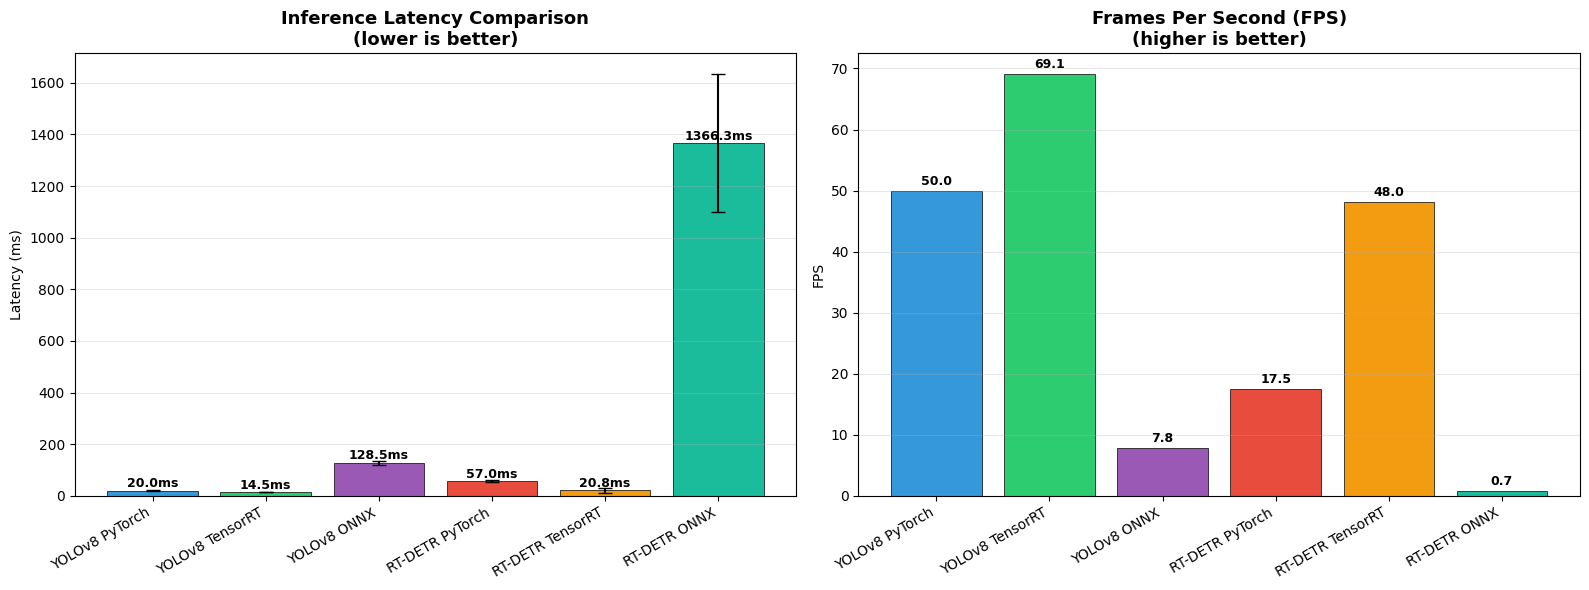

✅ Benchmark chart saved as benchmark_results.png!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

models = list(results.keys())
latencies = [results[m][0] for m in models]
stds = [results[m][1] for m in models]

colors = ['#3498db','#2ecc71','#9b59b6',  # YOLOv8 colors
          '#e74c3c','#f39c12','#1abc9c']   # RT-DETR colors

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Latency bar chart
bars = axes[0].bar(models, latencies, yerr=stds,
                   color=colors, capsize=5, edgecolor='black', linewidth=0.5)
axes[0].set_title('Inference Latency Comparison\n(lower is better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Latency (ms)')
axes[0].set_xticklabels(models, rotation=30, ha='right')
axes[0].grid(axis='y', alpha=0.3)
for bar, lat in zip(bars, latencies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{lat:.1f}ms', ha='center', va='bottom', fontsize=9, fontweight='bold')

# FPS bar chart
fps_values = [1000/l for l in latencies]
bars2 = axes[1].bar(models, fps_values, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Frames Per Second (FPS)\n(higher is better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('FPS')
axes[1].set_xticklabels(models, rotation=30, ha='right')
axes[1].grid(axis='y', alpha=0.3)
for bar, fps in zip(bars2, fps_values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{fps:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Benchmark chart saved as benchmark_results.png!")

TensorRT brought RT-DETR from barely real-time (17.5 FPS) all the way to 48 FPS, which is comfortably real-time for video. On the other hand, ONNX Runtime worked reasonably for the simple CNN-based YOLOv8 but failed badly for the transformer-based RT-DETR, it shows that not all acceleration methods suit all architectures.

In [20]:
%%writefile app.py
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
import uvicorn
import numpy as np
import cv2
import time
import base64
from ultralytics import YOLO
import io
from PIL import Image

app = FastAPI(title="Object Detection API")

# Allow frontend to talk to backend
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# Load all models at startup
print("Loading models...")
models = {
    "yolov8_pytorch": YOLO("yolov8n.pt"),
    "yolov8_tensorrt": YOLO("yolov8n.engine"),
    "rtdetr_pytorch":  YOLO("rtdetr-l.pt"),
    "rtdetr_tensorrt": YOLO("rtdetr-l.engine"),
}
print("✅ All models loaded!")

CLASS_NAMES = ["person", "bicycle", "car", "motorcycle", "bus", "truck"]
ALLOWED_CLASSES = [0, 1, 2, 3, 5, 7]  # COCO indices for our classes

def process_image(image_bytes):
    """Convert uploaded bytes to numpy image"""
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    return img

def image_to_base64(img):
    """Convert numpy image to base64 string for frontend"""
    _, buffer = cv2.imencode('.jpg', img)
    return base64.b64encode(buffer).decode('utf-8')

def run_detection(model, img, model_name):
    """Run detection and return results"""
    # Warmup for TensorRT
    if "tensorrt" in model_name:
        model(img, verbose=False)

    start = time.time()
    results = model(img, verbose=False)
    latency = (time.time() - start) * 1000

    detections = []
    annotated_img = results[0].plot()

    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        if cls_id in ALLOWED_CLASSES:
            detections.append({
                "label": model.names[cls_id],
                "confidence": round(float(box.conf[0]), 3),
                "bbox": {
                    "x1": round(float(box.xyxy[0][0])),
                    "y1": round(float(box.xyxy[0][1])),
                    "x2": round(float(box.xyxy[0][2])),
                    "y2": round(float(box.xyxy[0][3])),
                }
            })

    return detections, annotated_img, latency

# ─── ROUTES ───────────────────────────────────────────────

@app.get("/")
def root():
    return {"message": "Object Detection API is running! 🚀"}

@app.get("/models")
def list_models():
    """List all available models"""
    return {
        "models": list(models.keys()),
        "description": {
            "yolov8_pytorch":  "YOLOv8 baseline (PyTorch)",
            "yolov8_tensorrt": "YOLOv8 optimized (TensorRT)",
            "rtdetr_pytorch":  "RT-DETR baseline (PyTorch)",
            "rtdetr_tensorrt": "RT-DETR optimized (TensorRT)",
        }
    }

@app.post("/detect/image")
async def detect_image(
    file: UploadFile = File(...),
    model_name: str = "yolov8_pytorch"
):
    """Run object detection on uploaded image"""
    if model_name not in models:
        return JSONResponse(
            status_code=400,
            content={"error": f"Model '{model_name}' not found. Choose from: {list(models.keys())}"}
        )

    # Read and process image
    image_bytes = await file.read()
    img = process_image(image_bytes)

    # Run detection
    model = models[model_name]
    detections, annotated_img, latency = run_detection(model, img, model_name)

    # Convert annotated image to base64
    annotated_b64 = image_to_base64(annotated_img)

    return {
        "model": model_name,
        "latency_ms": round(latency, 2),
        "num_detections": len(detections),
        "detections": detections,
        "annotated_image": annotated_b64,
    }

@app.post("/detect/compare")
async def compare_models(file: UploadFile = File(...)):
    """Run all models on same image and compare"""
    image_bytes = await file.read()
    img = process_image(image_bytes)

    comparison = {}
    for model_name, model in models.items():
        detections, annotated_img, latency = run_detection(model, img, model_name)
        comparison[model_name] = {
            "latency_ms": round(latency, 2),
            "num_detections": len(detections),
            "detections": detections,
            "annotated_image": image_to_base64(annotated_img),
        }

    return {"comparison": comparison}

Writing app.py


## Starting server with ngrok tunnel

In [ ]:
import nest_asyncio
from pyngrok import ngrok
import uvicorn
import threading

nest_asyncio.apply()

# ⬇️ Paste your authtoken here
NGROK_TOKEN = "YOUR_NGROK_TOKEN_HERE"
ngrok.set_auth_token(NGROK_TOKEN)

# Start ngrok tunnel
ngrok.kill()
public_url = ngrok.connect(8001)
print(f"✅ Public API URL: {public_url}")
print(f"📖 API Docs: {public_url}/docs")
print(f"\n⭐ Save this URL for your React frontend!")

# Run FastAPI
config = uvicorn.Config("app:app", host="0.0.0.0", port=8001, log_level="warning")
server = uvicorn.Server(config)

thread = threading.Thread(target=server.run)
thread.daemon = True
thread.start()

print("🚀 Server is running!")

✅ Public API URL: NgrokTunnel: "https://nakia-noncalumniating-supportively.ngrok-free.dev" -> "http://localhost:8001"
📖 API Docs: NgrokTunnel: "https://nakia-noncalumniating-supportively.ngrok-free.dev" -> "http://localhost:8001"/docs

⭐ Save this URL for your React frontend!
🚀 Server is running!


ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8001): address already in use


## Testing API

In [ ]:
import requests

# Replace with your ngrok URL from Cell 13
API_URL = public_url.public_url

# Test root endpoint
response = requests.get(f"{API_URL}/")
print("Root:", response.json())

# Test models endpoint
response = requests.get(f"{API_URL}/models")
print("\nAvailable models:", response.json())

# Test image detection
with open("test_image.jpg", "rb") as f:
    response = requests.post(
        f"{API_URL}/detect/image",
        files={"file": f},
        params={"model_name": "yolov8_pytorch"}
    )

result = response.json()
print(f"\n✅ Detection test successful!")
print(f"Model: {result['model']}")
print(f"Latency: {result['latency_ms']}ms")
print(f"Detections: {result['num_detections']} objects found")
for d in result['detections']:
    print(f"  → {d['label']}: {d['confidence']} confidence")

Root: {'message': 'Object Detection API is running! 🚀'}

Available models: {'models': ['yolov8_pytorch', 'yolov8_tensorrt', 'rtdetr_pytorch', 'rtdetr_tensorrt'], 'description': {'yolov8_pytorch': 'YOLOv8 baseline (PyTorch)', 'yolov8_tensorrt': 'YOLOv8 optimized (TensorRT)', 'rtdetr_pytorch': 'RT-DETR baseline (PyTorch)', 'rtdetr_tensorrt': 'RT-DETR optimized (TensorRT)'}}

✅ Detection test successful!
Model: yolov8_pytorch
Latency: 144.98ms
Detections: 5 objects found
  → bus: 0.873 confidence
  → person: 0.866 confidence
  → person: 0.853 confidence
  → person: 0.825 confidence
  → person: 0.261 confidence
